In [ ]:
#import required libraries
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Since the dataset is in the same folder with our notebook, load dataset into a pandas framework using the code below.

dataset = pd.read_csv('Loan_Approval_Reject.csv')

In [ ]:
#Explore the datset using some function from pandas to give an understanding of our dataset.

dataset.describe()

#The Describe() funtion returns the statistical description of all the numerical variable in the dataframe.

,Income,Credit-Score,Loan_amount,Years_Employed,Points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [ ]:
#The Describe(include = 'all') function returns the statistical description of numerical variable of each column in the dataframe.

dataset.describe(include='all')

,Name,City,Income,Credit-Score,Loan_amount,Years_Employed,Points,Loan_Approved
count,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000
unique,2000,1882,NaN,NaN,NaN,NaN,NaN,2
top,Allison Hill,North Joseph,NaN,NaN,NaN,NaN,NaN,False
freq,1,4,NaN,NaN,NaN,NaN,NaN,1121
mean,NaN,NaN,90585.977000,573.946000,25308.503000,20.441000,56.680000,NaN
std,NaN,NaN,34487.874907,160.564945,14207.320147,11.777813,18.638033,NaN
min,NaN,NaN,30053.000000,300.000000,1022.000000,0.000000,10.000000,NaN
25%,NaN,NaN,61296.250000,433.000000,12748.750000,10.000000,45.000000,NaN
50%,NaN,NaN,90387.500000,576.000000,25661.500000,21.000000,55.000000,NaN
75%,NaN,NaN,120099.750000,715.000000,37380.500000,31.000000,70.000000,NaN


In [ ]:
dataset.head()

,Name,City,Income,Credit-Score,Loan_amount,Years_Employed,Points,Loan_Approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [ ]:
dataset.tail()

,Name,City,Income,Credit-Score,Loan_amount,Years_Employed,Points,Loan_Approved
1995,James Schaefer,Robertton,92163,770,12251,13,85,True
1996,Diana Lin,New Frank,38799,635,48259,17,40,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60,True
1998,Jason Price,Adamland,139022,360,24031,35,55,False
1999,Nicole Brown,New Nathantown,41188,482,31397,6,20,False


In [ ]:
dataset.shape

(2000, 8)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            2000 non-null   object
 1   City            2000 non-null   object
 2   Income          2000 non-null   int64 
 3   Credit-Score    2000 non-null   int64 
 4   Loan_amount     2000 non-null   int64 
 5   Years_Employed  2000 non-null   int64 
 6   Points          2000 non-null   int64 
 7   Loan_Approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


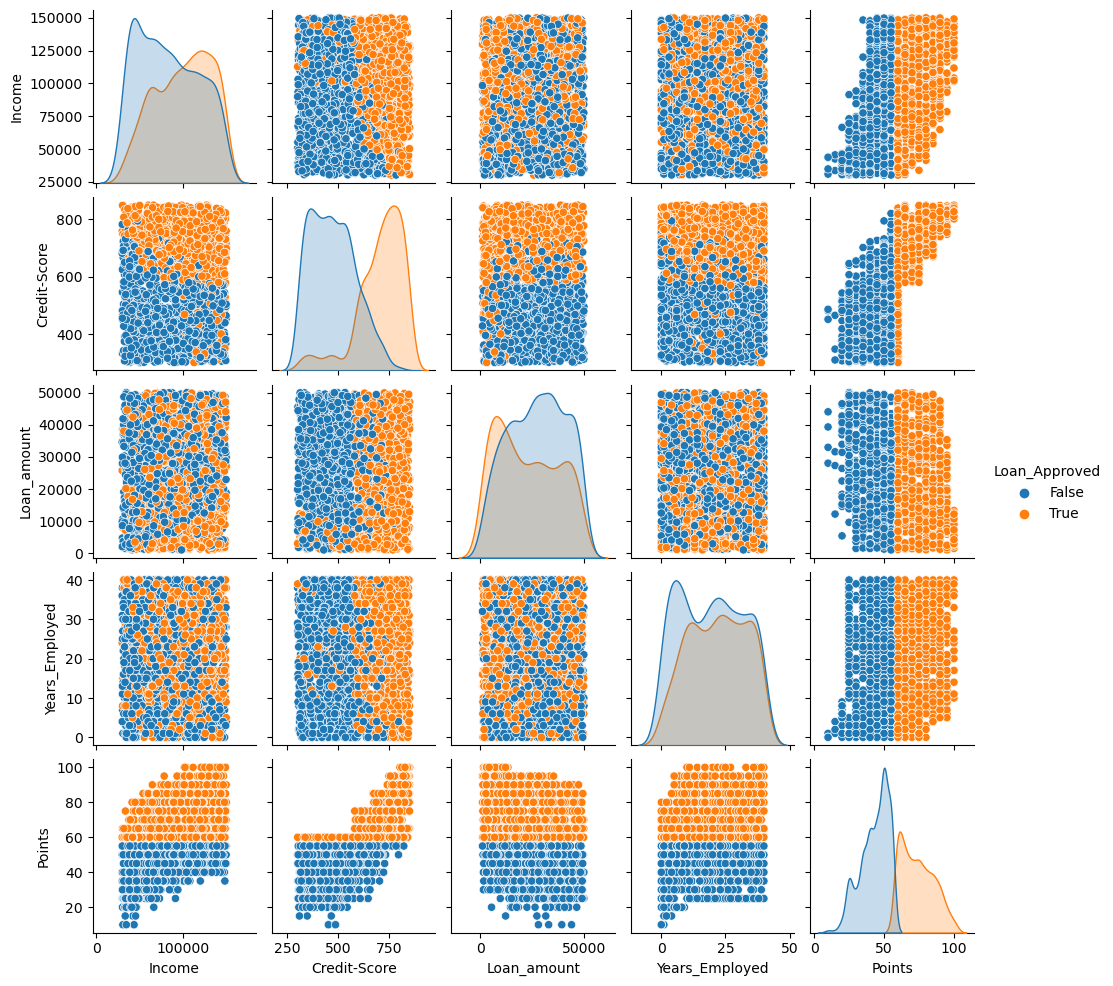

In [ ]:
#DATA VISUALIZATION. We can gain further pinsight about our dataset from visualizing the dataset,
#usining scatterred plot with the pairplot() function from pandas.

numeric_dataset = dataset.select_dtypes(include ='number')

numeric_dataset['Loan_Approved'] = dataset['Loan_Approved']


sns.pairplot(numeric_dataset, hue = 'Loan_Approved', height = 2)



In [ ]:
#Now the dataset is now ready for applying the chosen algorithm(K-Nearest Neighbors) K-NN. We proceed by determining
#the class feature/outcome feature,and the input feature/independent variable. The aim of this classification problem
#is to predict the class label of the dataset(Output/Outcome which will be denotated by y in our line of codes)
#based on its feature(Inputs/independent variable which will be denotated by X in our lines of codes.

In [ ]:
#Firstly we split our dataset into input & output.(Numerical Values only). Thereafter, we further slipt the dataset into,
#trainning data & testing data with the train_test_split function from sklearn.

X = dataset.iloc[:, 2:7].values

y = dataset['Loan_Approved'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

print('X_train_shape:' + str(X_train.shape)),
print('X_test_shape:' + str(X_test.shape)),
print('y_train_shape:' + str(y_train.shape)),
print('y_test_shape:' + str(y_test.shape))



X_train_shape:(1600, 5)
X_test_shape:(400, 5)
y_train_shape:(1600,)
y_test_shape:(400,)


In [ ]:
#The above result shows that our Input data have been divided into two; the train data which consist of 1600 samples and 5 feature,
#and the test data consisting of 400 samples and 5 features. The output/target(y) was also divided into two i.e the train data
#which consist of 1600 samples from the output variable and the test data consisting of 400 samples from the output variable.


In [ ]:
# Next, we apply some type of feature scaling(normalization) to our training data only(to avoid data leakage)
# to make it comparable.Standardization scales each input variable separately by subtracting the mean and dividing
# by the standard deviation to shift the distribution to have a mean of zero and a standard deviation of one.
# We should scale the training data by subtracting the mean and dividing by the standard deviation.
# We should use the same mean and standard deviation for scaling test data as well.


# fit_transform() method in Python is used on the training data so that we can scale the training data and
# also learn the scaling parameters of that data ( i.e., the
# mean and variance of each of the features in the training data). Then, scaling should be applied to the
# test data too. The transform() method helps us in this
# case and scale test data by the same mean and variance that is calculated from our training data.


from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_train_s = Scaler.fit_transform(X_train)
X_test_s = Scaler.transform(X_test)

print(X_train_s)
print(X_test_s)

[[ 1.02860223  0.37581346  0.20429149 -0.72514954  0.72167273]
 [-0.13729998  0.14438246 -0.25515669 -0.46932727  0.18210433]
 [-1.53925139 -1.41934056 -1.68172361 -1.0662459  -1.16681666]
 ...
 [ 0.95899872 -1.55694819 -1.48447582 -0.55460136  0.18210433]
 [ 1.1253285  -0.9940079  -1.44173645  1.23615452  0.18210433]
 [-0.84327427  1.4516549  -0.67249816  0.63923589  1.26124113]]
[[-0.7130792   0.7385972  -1.1128964  -0.98097181  0.45188853]
 [ 1.66245199  0.63851893  0.95567484 -0.46932727  0.99145693]
 [-1.22122537  1.09512605 -0.58062259 -0.72514954  0.45188853]
 ...
 [-0.11672609 -0.57493013  0.08978092  1.49197679 -0.62724826]
 [-0.93663918 -1.57571286 -1.49326269  0.04231727 -0.35746406]
 [-0.44272087 -0.78759646  1.11587717 -0.38405318 -0.89703246]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 40)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    accuracy_scores.append(accuracy_score(y_test, y_pred))


best_k = k_values[accuracy_scores.index(max(accuracy_scores))]

print(best_k)
print(accuracy_scores)



12
[0.9725, 0.97, 0.975, 0.975, 0.975, 0.98, 0.9775, 0.9875, 0.98, 0.985, 0.9875, 0.99, 0.99, 0.99, 0.985, 0.9875, 0.99, 0.9875, 0.9825, 0.985, 0.98, 0.985, 0.9825, 0.98, 0.98, 0.9775, 0.98, 0.9825, 0.975, 0.98, 0.985, 0.9825, 0.98, 0.98, 0.9825, 0.9825, 0.9825, 0.9775, 0.97]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1, 40)}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train_s, y_train)

print("Best k:", grid.best_params_)
print("Best accuracy:", grid.best_score_)


Best k: {'n_neighbors': 4}
Best accuracy: 0.9875


In [ ]:
#The methods used in determinig k values produced k=4.
#We will train our model on the value  k=4,


from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=4, metric = 'minkowski', p=2)
classifier.fit(X_train_s,y_train)

KNeighborsClassifier(n_neighbors=4)

In [ ]:
# Evaluating the model:
#Once the model is trained, we can use the ‘predict’ function on our model to make predictions on our test data.

y_pred = classifier.predict(X_test_s)

print(y_pred)



[ True  True  True  True False False  True False False False  True  True
 False False  True False  True  True False False False False False False
 False  True  True False False False False False  True  True False False
  True False False False False False  True  True False  True False False
 False  True  True False False False False False False False False False
 False False  True False False  True False  True False False False  True
 False False False  True False False  True False False False  True False
  True  True  True False  True False False False False False  True False
  True False  True False  True  True False  True False False False False
 False  True  True False False False  True False False False False  True
 False  True False False  True  True  True False False False  True  True
  True False False  True  True  True  True  True False False False False
  True  True  True  True False False  True False  True False  True False
 False  True False  True  True False  True  True Fa

In [ ]:
print(y_test)

[ True  True  True  True False False  True False  True False  True  True
 False False  True False  True  True False False False False False False
 False  True  True False False False False False  True  True False False
  True False False False False False  True  True False  True False False
 False  True  True False False False False False False False False False
 False False  True False False  True False  True False False False False
 False False False  True False False  True False False False  True False
  True  True  True False  True False False False False False  True False
  True False  True False  True  True False  True False False False False
 False  True  True False False False  True False False False False  True
 False  True False False  True  True  True False False False  True  True
  True False False  True  True  True  True  True False False False False
  True  True  True  True False False  True False  True False  True False
 False  True False  True  True False  True  True Fa

In [ ]:
#To evaluate the performance of model, you can use the following code:
from sklearn import metrics
acc=metrics.accuracy_score(y_test,y_pred)
print('accuracy:%.2f\n\n'%(acc))
cm=metrics.confusion_matrix(y_test,y_pred)
print('Confusion, Matrix:')
print(cm,'n\n')
print('........................................')
result=metrics.classification_report(y_test,y_pred)
print('Classification Report:\n')
print(result)

accuracy:0.97


Confusion, Matrix:
[[217   7]
 [  3 173]] n

........................................
Classification Report:

              precision    recall  f1-score   support

       False       0.99      0.97      0.98       224
        True       0.96      0.98      0.97       176

    accuracy                           0.97       400
   macro avg       0.97      0.98      0.97       400
weighted avg       0.98      0.97      0.98       400



In [ ]:
#The confusion_matrix function generates a confusion matrix using the generated
#predictions (y_pred) and the true class labels for the test data (y_test). It shows the number of TP, FN, FP and TN.
#The classification_report function shows different metrics such as precision, recall, f1-score, etc., for model evaluation

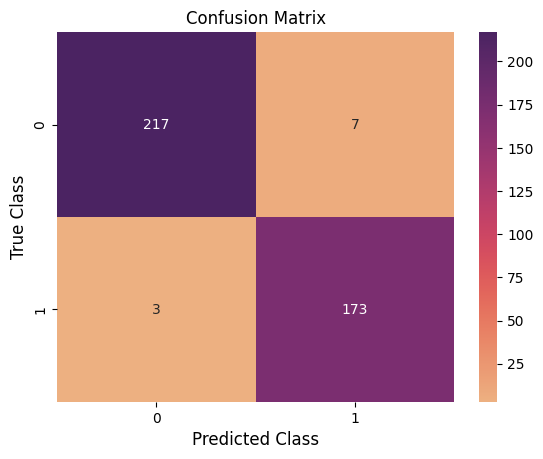

In [ ]:
#Also, we can use the seaborn heatmap to visualise the confusion matrix.
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.heatmap(cm, cmap='flare', annot=True, fmt='d')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix")
plt.show()
